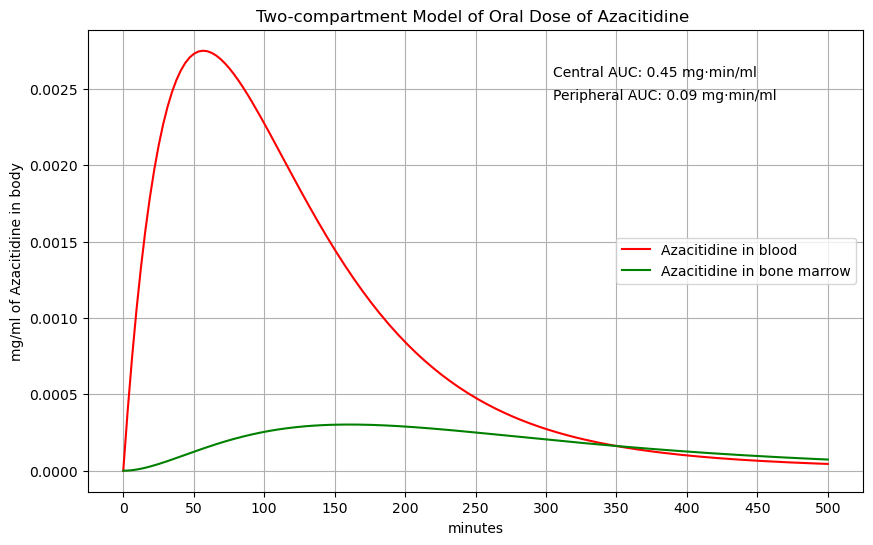

In [27]:
import numpy as np
from scipy.integrate import trapezoid 
from scipy.integrate import odeint
import matplotlib.pyplot as plt


def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    C1,C2 = y

    F = 0.115 #percent absorbed by the body, bioavailability ~11.5% for oral dose of 300mg (https://pmc.ncbi.nlm.nih.gov/articles/PMC3675699/)
    ka = 0.0173 #the first order absorption rate constant, 0.0173/min which was converted from 1.04/hr (https://ascpt.onlinelibrary.wiley.com/doi/10.1002/cpt.2982)
    D0 = 300 #dose of the drug, 300mg #common dose for Oral azacitidine drug, Onurag
    Vd = 81500 # volume of distribution of central compartment (one of saanvis sources)
    k = 0.0169 #rate constant of elimination  = ln(2)/halflife -> ln(2)/30mins = 0.0169 #
    k12 = 0.00149  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
    k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model)
    #rate at which azacitidine leaves the gut to go into blood - rate it leaves blood to go into marrow +rate it goes back into blood from marrow
    dC1dt = F*ka*D0*np.exp(-ka*t)/4500 - (k + k12)*C1 + k21*C2 
    #dC1dt = ((ka*D0*F)/(Vd*(ka-k)) * (-k*np.exp(-k*t) + ka*np.exp(-ka*t)))  
    dC2dt = k12*C1 - k21*C2
    return [dC1dt,dC2dt]



C1 = 0
C2 = 0
t = np.linspace(0,500, 160)    
y0 = C1,C2
ret = odeint(Aza_Effect,y0,t)
C1,C2 = ret.T
plt.figure(figsize=(10, 6))
plt.plot(t, C1, 'r', label='Azacitidine in blood')
plt.plot(t, C2, 'g', label='Azacitidine in bone marrow')

tb = np.linspace(0,500, 160)  



auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t)
plt.annotate(f"Central AUC: {auc_central:.2f} mg·min/ml", xy=(0.6, 0.9), xycoords='axes fraction')
plt.annotate(f"Peripheral AUC: {auc_peripheral:.2f} mg·min/ml", xy=(0.6, 0.85), xycoords='axes fraction')

plt.title('Two-compartment Model of Oral Dose of Azacitidine ')
plt.xlabel('minutes')
plt.xticks([0,50,100,150,200,250,300,350,400,450,500])
plt.ylabel('mg/ml of Azacitidine in body')
plt.legend()
plt.grid(True)
plt.show()